In [8]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/AB_US_2020_cleaned.csv")

In [3]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/processed/airbnb.db")

In [ ]:
import pandas as pd

query = """
SELECT 
    city,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(AVG(reviews_per_month), 2) as avg_reviews_per_month,
    ROUND(AVG(price) * AVG(reviews_per_month) * 12, 2) as est_annual_revenue_proxy
FROM listings
GROUP BY city
HAVING COUNT(*) > 1000
ORDER BY est_annual_revenue_proxy DESC;
"""

city_summary = pd.read_sql(query, engine)
city_summary

,city,total_listings,avg_price,avg_reviews_per_month,est_annual_revenue_proxy
0,Santa Cruz County,1563,248.33,1.74,5186.44
1,Asheville,2070,155.96,2.68,5016.14
2,Nashville,6113,204.90,1.95,4782.76
3,Columbus,1382,142.77,2.33,3987.35
4,Portland,4274,134.98,2.26,3662.01
5,San Mateo County,2840,178.67,1.66,3559.06
6,San Diego,12210,209.98,1.39,3506.60
7,Twin Cities MSA,5974,311.17,0.94,3494.94
8,Rhode Island,3852,270.15,1.07,3484.95
9,Denver,4186,147.84,1.84,3268.81


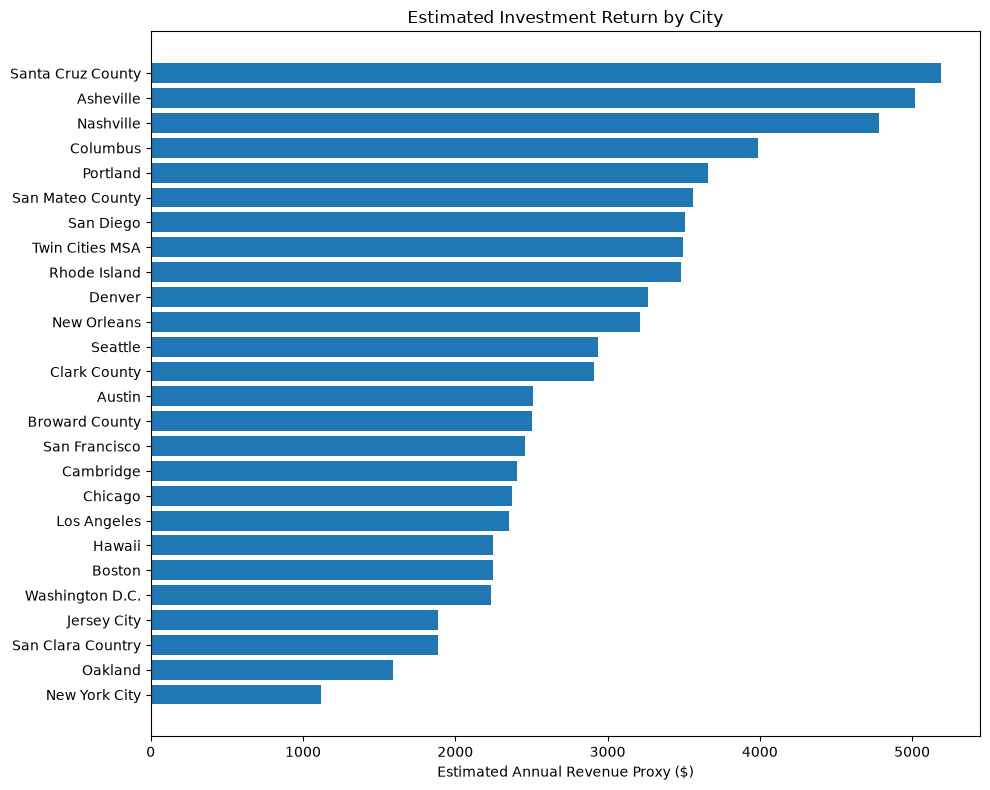

In [5]:
import matplotlib.pyplot as plt

city_summary_sorted = city_summary.sort_values('est_annual_revenue_proxy', ascending=True)
plt.figure(figsize=(10,8))
plt.barh(city_summary_sorted['city'], city_summary_sorted['est_annual_revenue_proxy'])
plt.xlabel("Estimated Annual Revenue Proxy ($)")
plt.title("Estimated Investment Return by City")
plt.tight_layout()
plt.savefig("../images/revenue_by_city.png", dpi=150)
plt.show()

In [6]:
query2 = """
SELECT 
    room_type,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(AVG(reviews_per_month), 2) as avg_reviews_per_month,
    ROUND(AVG(price) * AVG(reviews_per_month) * 12, 2) as est_annual_revenue_proxy
FROM listings
GROUP BY room_type
ORDER BY est_annual_revenue_proxy DESC;
"""

room_summary = pd.read_sql(query2, engine)
room_summary

,room_type,total_listings,avg_price,avg_reviews_per_month,est_annual_revenue_proxy
0,Entire home/apt,152029,219.55,1.22,3206.96
1,Hotel room,1886,238.48,1.09,3132.43
2,Private room,65682,94.56,0.97,1102.96
3,Shared room,4013,61.07,0.57,417.66


Correlation between price and reviews_per_month: -0.140


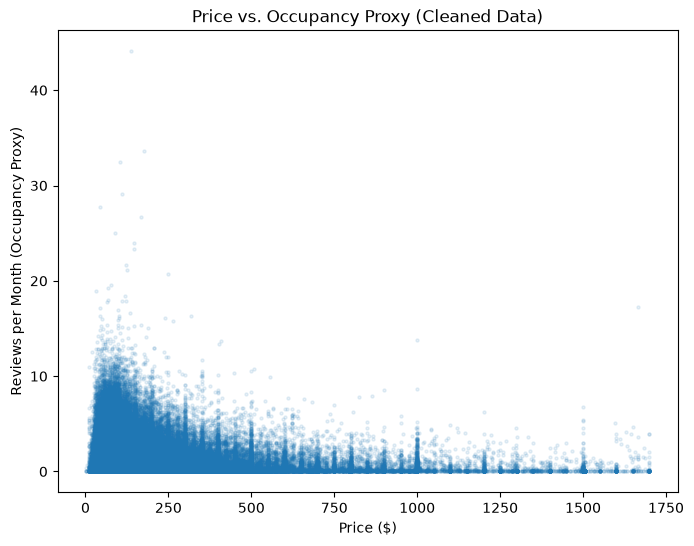

In [9]:
correlation = df_clean[['price', 'reviews_per_month']].corr().iloc[0,1]
print(f"Correlation between price and reviews_per_month: {correlation:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(df_clean['price'], df_clean['reviews_per_month'], alpha=0.1, s=5)
plt.xlabel("Price ($)")
plt.ylabel("Reviews per Month (Occupancy Proxy)")
plt.title("Price vs. Occupancy Proxy (Cleaned Data)")
plt.savefig("../images/price_vs_occupancy.png", dpi=150)
plt.show()

In [10]:
df_clean['host_type'] = df_clean['calculated_host_listings_count'].apply(
    lambda x: 'Professional/Business' if x > 10 else 'Individual Host'
)

query4 = df_clean.groupby('host_type').agg(
    avg_price=('price', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
    total_listings=('id', 'count')
).round(2)

query4

,avg_price,avg_reviews_per_month,total_listings
host_type,,,
Individual Host,170.52,1.23,179575
Professional/Business,219.40,0.72,44035


In [11]:
top_city = city_summary.iloc[0]['city']  # adjust if you want a different one

query5 = f"""
SELECT 
    neighbourhood,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(AVG(reviews_per_month), 2) as avg_reviews_per_month
FROM listings
WHERE city = '{top_city}'
GROUP BY neighbourhood
HAVING COUNT(*) > 20
ORDER BY avg_price * avg_reviews_per_month DESC
LIMIT 10;
"""

neighborhood_summary = pd.read_sql(query5, engine)
neighborhood_summary

,neighbourhood,total_listings,avg_price,avg_reviews_per_month
0,Unincorporated Areas,879,244.68,1.85
1,City of Scotts Valley,26,200.15,2.22
2,City of Capitola,184,295.98,1.47
3,City of Santa Cruz,459,243.30,1.63


In [12]:
city_summary.to_csv("../data/processed/tableau_city_summary.csv", index=False)
room_summary.to_csv("../data/processed/tableau_room_summary.csv", index=False)
query4.reset_index().to_csv("../data/processed/tableau_host_type_summary.csv", index=False)

# Also export a neighborhood-level file across ALL cities (not just Santa Cruz), for a fuller dashboard
all_neighborhoods_query = """
SELECT 
    city,
    neighbourhood,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(AVG(reviews_per_month), 2) as avg_reviews_per_month
FROM listings
GROUP BY city, neighbourhood
HAVING COUNT(*) > 20;
"""
neighborhood_all = pd.read_sql(all_neighborhoods_query, engine)
neighborhood_all.to_csv("../data/processed/tableau_neighborhood_summary.csv", index=False)

print("All Tableau export files saved successfully.")

All Tableau export files saved successfully.
